In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from pathlib import Path
import sys

from statsmodels.tsa.seasonal import STL

import plotly.graph_objects as go
from plotly.subplots import make_subplots

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

from feature_engine.datetime import DatetimeFeatures
from feature_engine.creation import CyclicalFeatures

from lightgbm import LGBMRegressor

from skforecast.preprocessing import RollingFeatures
from sklearn.feature_selection import RFECV
from skforecast.feature_selection import select_features

from skforecast.direct import ForecasterDirect
from skforecast.recursive import ForecasterEquivalentDate, ForecasterRecursive
from skforecast.model_selection import TimeSeriesFold, bayesian_search_forecaster, backtesting_forecaster

import warnings
warnings.filterwarnings('once')

def _project_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "src" / "forecasting").is_dir():
            return p
    return here


_root = _project_root()
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))

from forecasting.data.loaders import load_market_data
from forecasting.features.market import add_daily_clf, add_nci, add_rolling_3d_clf

In [6]:
data_indexed = load_market_data("../../../data/raw/iex-dam-0201-0421.csv")

### Naive Seasonal Forecast

In [42]:
forecaster = ForecasterEquivalentDate(
                 offset    = pd.DateOffset(days=7),
                 n_offsets = 1
             )
forecaster.fit(y=data_indexed.loc[:, 'purchase_bid'])
forecaster

======================== 
ForecasterEquivalentDate 
======================== 
Offset: <DateOffset: days=7> 
Number of offsets: 1 
Aggregation function: mean 
Window size: 672 
Series name: purchase_bid 
Training range: [Timestamp('2026-02-01 00:00:00'), Timestamp('2026-04-21 23:45:00')] 
Training index type: DatetimeIndex 
Training index frequency: <15 * Minutes> 
Creation date: 2026-04-23 19:35:44 
Last fit date: 2026-04-23 19:35:44 
Skforecast version: 0.21.0 
Python version: 3.12.13 
Forecaster id: None

In [49]:
cv = TimeSeriesFold(
        steps              = 96*7,
        initial_train_size = len(data_indexed)-96*7,
        refit              = False
)
metric, predictions = backtesting_forecaster(
                          forecaster = forecaster,
                          y          = data_indexed['purchase_bid'],
                          cv         = cv,
                          metric     = 'mean_absolute_error'
                       )

  0%|          | 0/1 [00:00<?, ?it/s]

In [50]:
display(metric)
predictions.head()

,mean_absolute_error
0,4846.740179


,fold,pred
2026-04-15 00:00:00,0,12228.6
2026-04-15 00:15:00,0,12178.0
2026-04-15 00:30:00,0,12444.5
2026-04-15 00:45:00,0,12719.5
2026-04-15 01:00:00,0,12814.5


In [51]:
fig = go.Figure()
trace1 = go.Scatter(x=data_indexed.index, y=data_indexed['purchase_bid'], name="test", mode="lines")
trace2 = go.Scatter(x=predictions.index, y=predictions['pred'], name="prediction", mode="lines")
fig.add_trace(trace1)
fig.add_trace(trace2)
fig.update_layout(
    title="Real value vs predicted in test data",
    xaxis_title="Date time",
    yaxis_title="Demand",
    width=800,
    height=400,
    margin=dict(l=20, r=20, t=35, b=20),
    legend=dict(orientation="h", yanchor="top", y=1.01, xanchor="left", x=0)
)
fig.show()

### LightGBM Regressor

In [60]:
cv_lgbm = TimeSeriesFold(
        steps              = 96*7,
        initial_train_size = len(data_indexed)-96*7,
        refit              = False
)

In [61]:
# Create forecaster
# ==============================================================================
window_features = RollingFeatures(stats=["mean"], window_sizes=96 * 3)
forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 96*3,
                 window_features = window_features
             )

# Train forecaster
# ==============================================================================
forecaster.fit(y=data_indexed.loc[:, 'purchase_bid'])
forecaster

=================== 
ForecasterRecursive 
=================== 
Estimator: LGBMRegressor 
Lags: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252
 253 254 255 256 257 258 259 260 261 262 263 264 265 266 267 268 269 270
 271 272 273 274 275 276 277 278 279 280 281 282 283 284 285 286 287 288] 
Window features: ['roll_mean_288'] 
Window size: 288 
Series name: purchase_bid 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2026-02-01 00:00:00'), Timestamp('2026-04-21 23:45:00')] 
Training index type: DatetimeIndex 
Training index frequency: <15 * Minutes> 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 15926, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample':
    1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-04-23 20:15:21 
Last fit date: 2026-04-23 20:15:23 
Skforecast version: 0.21.0 
Python version: 3.12.13 
Forecaster id: None

In [62]:
metric, predictions = backtesting_forecaster(
                          forecaster    = forecaster,
                          y             = data_indexed['purchase_bid'],
                          cv            = cv_lgbm,
                          metric        = 'mean_absolute_error',
                          verbose       = True, # Set to False to avoid printing
                          return_predictors = True,
                      )

Information of folds
--------------------
Number of observations used for initial training: 7008
Number of observations used for backtesting: 672
    Number of folds: 1
    Number skipped folds: 0 
    Number of steps per fold: 672
    Number of steps to exclude between last observed data (last window) and predictions (gap): 0

Fold: 0
    Training:   2026-02-01 00:00:00 -- 2026-04-14 23:45:00  (n=7008)
    Validation: 2026-04-15 00:00:00 -- 2026-04-21 23:45:00  (n=672)



  0%|          | 0/1 [00:00<?, ?it/s]

In [63]:
fig = go.Figure()
trace1 = go.Scatter(x=data_indexed.index, y=data_indexed['purchase_bid'], name="test", mode="lines")
trace2 = go.Scatter(x=predictions.index, y=predictions['pred'], name="prediction", mode="lines")
fig.add_trace(trace1)
fig.add_trace(trace2)
fig.update_layout(
    title="Real value vs predicted in test data",
    xaxis_title="Date time",
    yaxis_title="Demand",
    width=800,
    height=400,
    margin=dict(l=20, r=20, t=35, b=20),
    legend=dict(orientation="h", yanchor="top", y=1.01, xanchor="left", x=0)
)
fig.show()

In [64]:
# forecaster.get_feature_importances().head(10)
metric

,mean_absolute_error
0,4770.722974


### Including exogenuous variable

In [65]:
features_to_extract = [
    'day_of_week',
    'hour'
]
max_values = {
    "day_of_week": 7,
    "hour": 24,
}
calendar_transformer = DatetimeFeatures(
    variables           = 'index',
    features_to_extract = features_to_extract,
    drop_original       = True,
)
calendar_features = calendar_transformer.fit_transform(data_indexed)[features_to_extract]
cyclical_encoder = CyclicalFeatures(
    variables     = features_to_extract,
    max_values    = max_values,
    drop_original = False
)

exogenous_features = cyclical_encoder.fit_transform(calendar_features)
exogenous_features.head(3)

,day_of_week,hour,day_of_week_sin,day_of_week_cos,hour_sin,hour_cos
period_start,,,,,,
2026-02-01 00:00:00,6,0,-0.781831,0.62349,0.0,1.0
2026-02-01 00:15:00,6,0,-0.781831,0.62349,0.0,1.0
2026-02-01 00:30:00,6,0,-0.781831,0.62349,0.0,1.0


In [66]:
exog_features = exogenous_features.filter(regex='_sin$|_cos$').columns.tolist()
exog_features = exog_features + ['rolling_3d_clf']

In [69]:
market_with_weather = add_nci(data_indexed)
market_with_weather = add_daily_clf(market_with_weather)
market_with_weather = add_rolling_3d_clf(market_with_weather)
rolling_clf = market_with_weather.set_index('period_start')[['rolling_3d_clf']]

cyclical_exog = exogenous_features.filter(regex='_sin$|_cos$')
data_exog = data_indexed[['purchase_bid']].merge(
           cyclical_exog,
           left_index  = True,
           right_index = True,
           how         = 'inner'  # Use only dates for which we have all the variables
       )
data_exog = data_exog.merge(rolling_clf, left_index=True, right_index=True, how='inner')
data_exog = data_exog.astype('float32')
data_exog.head(5)

2026-04-23 20:23:06,928 | INFO | forecasting.features.market | Loading weather master from /Users/dhruvil/Documents/EarthSync/data/weather/weather_master.csv


,purchase_bid,day_of_week_sin,day_of_week_cos,hour_sin,hour_cos,rolling_3d_clf
period_start,,,,,,
2026-02-01 00:00:00,11446.599609,-0.781832,0.62349,0.000000,1.000000,0.0
2026-02-01 00:15:00,12066.799805,-0.781832,0.62349,0.000000,1.000000,0.0
2026-02-01 00:30:00,12510.900391,-0.781832,0.62349,0.000000,1.000000,0.0
2026-02-01 00:45:00,12502.599609,-0.781832,0.62349,0.000000,1.000000,0.0
2026-02-01 01:00:00,12423.799805,-0.781832,0.62349,0.258819,0.965926,0.0


In [70]:
metric, predictions = backtesting_forecaster(
                          forecaster = forecaster,
                          y          = data_exog['purchase_bid'],
                          exog       = data_exog[exog_features],
                          cv         = cv,
                          metric     = 'mean_absolute_error'
                      )
display(metric)
predictions.head()

  0%|          | 0/1 [00:00<?, ?it/s]

,mean_absolute_error
0,4147.017109


,fold,pred
2026-04-15 00:00:00,0,15499.582930
2026-04-15 00:15:00,0,16208.356096
2026-04-15 00:30:00,0,16695.000801
2026-04-15 00:45:00,0,16598.814550
2026-04-15 01:00:00,0,16612.618635


In [71]:
fig = go.Figure()
trace1 = go.Scatter(x=data_indexed.index, y=data_indexed['purchase_bid'], name="test", mode="lines")
trace2 = go.Scatter(x=predictions.index, y=predictions['pred'], name="prediction", mode="lines")
fig.add_trace(trace1)
fig.add_trace(trace2)
fig.update_layout(
    title="Real value vs predicted in test data",
    xaxis_title="Date time",
    yaxis_title="Demand",
    width=800,
    height=400,
    margin=dict(l=20, r=20, t=35, b=20),
    legend=dict(orientation="h", yanchor="top", y=1.01, xanchor="left", x=0)
)
fig.show()

### Tuning Forcaster Arguments via Bayesian Search

In [72]:
forecaster_bs_tuned = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 96,  # This value will be replaced in the grid search
                 window_features = window_features
             )

lags_grid = [300, (1, 2, 3, 95, 96, 97, 191, 192, 193, 287, 288, 289)]

def search_space(trial):
    search_space  = {
        'n_estimators' : trial.suggest_int('n_estimators', 300, 1000, step=100),
        'max_depth'    : trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5),
        'reg_alpha'    : trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda'   : trial.suggest_float('reg_lambda', 0, 1),
        'lags'         : trial.suggest_categorical('lags', lags_grid)
    } 
    return search_space

cv_search = TimeSeriesFold(
                steps              = 96*7,
                initial_train_size = len(data_indexed)-96*10,
                refit              = False,
            )

In [73]:
results_search, frozen_trial = bayesian_search_forecaster(
                                   forecaster   = forecaster_bs_tuned,
                                   y            = data_exog.loc[:, 'purchase_bid'],
                                   exog         = data_exog.loc[:, exog_features],
                                   cv           = cv_search,
                                   metric       = 'mean_absolute_error',
                                   search_space = search_space,
                                   n_trials     = 10,  # Increase for more exhaustive search
                                   return_best  = True
                               )

/Users/dhruvil/Documents/EarthSync/es_env/lib/python3.12/site-packages/skforecast/model_selection/_search.py:839: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  kwargs_create_study['sampler'] = TPESampler(
/Users/dhruvil/Documents/EarthSync/es_env/lib/python3.12/site-packages/skforecast/model_selection/_search.py:839: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  kwargs_create_study['sampler'] = TPESampler(


  0%|          | 0/10 [00:00<?, ?it/s]

In [74]:
# Search results
# ==============================================================================
best_params = results_search.at[0, 'params']
best_params = best_params | {'random_state': 15926, 'verbose': -1}
best_lags = results_search.at[0, 'lags']
results_search.head(3)

,trial_number,lags,params,mean_absolute_error,n_estimators,max_depth,learning_rate,reg_alpha,reg_lambda
0,4,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'n_estimators': 500, 'max_depth': 8, 'learnin...",3222.173979,500.0,8.0,0.055131,0.433701,0.430863
1,2,"[1, 2, 3, 95, 96, 97, 191, 192, 193, 287, 288,...","{'n_estimators': 600, 'max_depth': 8, 'learnin...",3532.192515,600.0,8.0,0.099421,0.175452,0.531551
2,3,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'n_estimators': 900, 'max_depth': 8, 'learnin...",3573.600924,900.0,8.0,0.309402,0.722443,0.322959


In [79]:
cv_tuned = TimeSeriesFold(
        steps              = 96*7,
        initial_train_size = len(data_indexed)-96*7,
        refit              = False
)
metric, predictions = backtesting_forecaster(
                          forecaster = forecaster_bs_tuned,
                          y          = data_exog['purchase_bid'],
                          exog       = data_exog[exog_features],
                          cv         = cv_tuned,
                          metric     = 'mean_absolute_error'
                      )
display(metric)
predictions.head()

  0%|          | 0/1 [00:00<?, ?it/s]

,mean_absolute_error
0,3865.530963


,fold,pred
2026-04-15 00:00:00,0,15729.066564
2026-04-15 00:15:00,0,16412.681247
2026-04-15 00:30:00,0,16906.000961
2026-04-15 00:45:00,0,17093.001701
2026-04-15 01:00:00,0,17121.274262


In [80]:
fig = go.Figure()
trace1 = go.Scatter(x=data_indexed.index, y=data_indexed['purchase_bid'], name="test", mode="lines")
trace2 = go.Scatter(x=predictions.index, y=predictions['pred'], name="prediction", mode="lines")
fig.add_trace(trace1)
fig.add_trace(trace2)
fig.update_layout(
    title="Real value vs predicted in test data",
    xaxis_title="Date time",
    yaxis_title="Demand",
    width=800,
    height=400,
    margin=dict(l=20, r=20, t=35, b=20),
    legend=dict(orientation="h", yanchor="top", y=1.01, xanchor="left", x=0)
)
fig.show()

In [84]:
predictions[["pred"]].to_csv("../../../data/predictions/pb_predictions_0415_0421.csv")

### Feature Selection

In [77]:
# Create forecaster
# ==============================================================================
estimator = LGBMRegressor(
                n_estimators = 200,
                max_depth    = 3,
                random_state = 15926,
                verbose      = -1
            )

forecaster = ForecasterRecursive(
                 estimator       = estimator,
                 lags            = best_lags,
                 window_features = window_features
             )

# Recursive feature elimination with cross-validation
# ==============================================================================
warnings.filterwarnings("ignore", message="X does not have valid feature names.*")
selector = RFECV(
    estimator = estimator,
    step      = 1,
    cv        = 3,
)
lags_select, window_features_select, exog_select = select_features(
    forecaster      = forecaster,
    selector        = selector,
    y               = data_exog['purchase_bid'],
    exog            = data_exog[exog_features],
    select_only     = None,
    force_inclusion = None,
    subsample       = 0.5,  # Subsample to speed up the process
    random_state    = 123,
    verbose         = True,
)

Recursive feature elimination (RFECV)
-------------------------------------
Total number of records available: 7380
Total number of records used for feature selection: 3690
Number of features available: 306
    Lags            (n=300)
    Window features (n=1)
    Exog            (n=5)
Number of features selected: 68
    Lags            (n=64) : [1, 3, 4, 6, 7, 11, 13, 14, 18, 20, 26, 28, 32, 35, 53, 67, 68, 77, 87, 89, 90, 91, 93, 94, 95, 96, 97, 98, 99, 100, 101, 108, 115, 120, 136, 137, 174, 179, 186, 190, 191, 192, 193, 195, 197, 210, 213, 217, 230, 231, 234, 248, 254, 264, 266, 271, 282, 285, 286, 287, 288, 289, 290, 292]
    Window features (n=0) : []
    Exog            (n=4) : ['day_of_week_sin', 'hour_sin', 'hour_cos', 'rolling_3d_clf']


In [ ]:
forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(**best_params),
                 lags            = lags_select,
                 window_features = window_features_select
             )
forecaster.fit(
    y               = data_exog['purchase_bid'],
    exog            = data_exog[exog_select],
)

TypeError: ForecasterRecursive.__init__() got an unexpected keyword argument 'exog_features'

### Predict 7 days

In [ ]:
import pandas as pd
import numpy as np

# 1. Create the future index (672 steps = 7 days * 96 periods)
last_date = data_exog.index[-1]
future_index = pd.date_range(
    start = last_date + pd.Timedelta(minutes=15), 
    periods = 96 * 7, 
    freq = '15min'
)

# 2. Generate the raw time components
# Matching the logic from your cell [222]
future_day_of_week = future_index.dayofweek + 1  # 1 (Mon) to 7 (Sun)
future_hour = future_index.hour

# 3. Apply Cyclical Encoding (Matching your cell [223] max_values)
# day_of_week (max=7), hour (max=24)
exog_future = pd.DataFrame(index=future_index)
exog_future['day_of_week_sin'] = np.sin(2 * np.pi * future_day_of_week / 7)
exog_future['day_of_week_cos'] = np.cos(2 * np.pi * future_day_of_week / 7)
exog_future['hour_sin'] = np.sin(2 * np.pi * future_hour / 24)
exog_future['hour_cos'] = np.cos(2 * np.pi * future_hour / 24)
exog_future['rolling_3d_clf'] = data_exog['rolling_3d_clf'].iloc[-1]

# 4. Display the result
print(f"Created exog features from {exog_future.index[0]} to {exog_future.index[-1]}")
display(exog_future.head())

In [282]:
forecaster_bs_tuned.fit(
    y = data_exog['purchase_bid'],
    exog = data_exog[exog_features] # Uncomment if using exogenous variables
)
predictions_future = forecaster_bs_tuned.predict(steps=672, exog=exog_future)

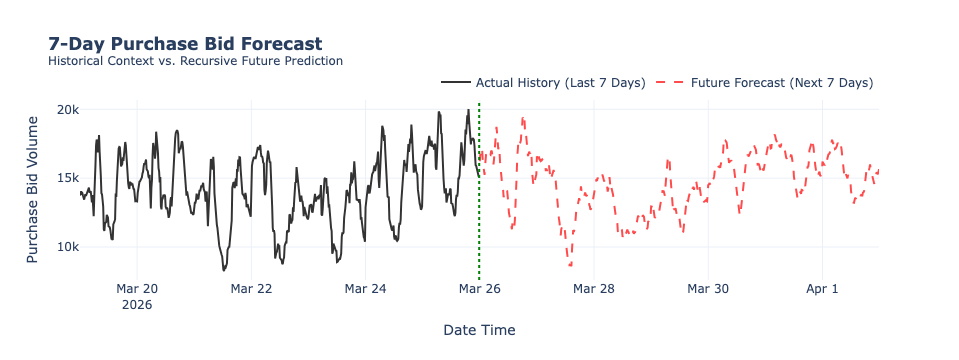

In [283]:
import plotly.graph_objects as go

# 1. Prepare the Past Data (Last 7 days of training)
# 96 periods * 7 days = 672
past_7_days = data_exog['purchase_bid'].tail(96 * 7)

# 2. Prepare the Future Data
# Ensure 'predictions_future' is the output from your .predict() call
# and it has the DatetimeIndex we created in the previous step.

fig = go.Figure()

# Plot Actual Past Data
fig.add_trace(go.Scatter(
    x=past_7_days.index, 
    y=past_7_days, 
    name="Actual History (Last 7 Days)", 
    line=dict(color='#333333', width=2)
))

# Plot Future Forecast
fig.add_trace(go.Scatter(
    x=predictions_future.index, 
    y=predictions_future, 
    name="Future Forecast (Next 7 Days)", 
    line=dict(color='#FF4B4B', width=2, dash='dash')
))

# Add a vertical line to mark the "Present" moment
fig.add_vline(
    x=past_7_days.index[-1], 
    line_width=2, 
    line_dash="dot", 
    line_color="green"
)

# Formatting
fig.update_layout(
    title="<b>7-Day Purchase Bid Forecast</b><br><sup>Historical Context vs. Recursive Future Prediction</sup>",
    xaxis_title="Date Time",
    yaxis_title="Purchase Bid Volume",
    template="plotly_white",
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.show()

In [285]:
df_predictions = predictions_future.to_frame(name='predictions')
df_predictions = df_predictions.reset_index().rename(columns={'index': 'period_start'})
start_str = df_predictions['period_start'].iloc[0].strftime('%m%d')
end_str = df_predictions['period_start'].iloc[-1].strftime('%m%d')
filename = f"boost_predictions_{start_str}_{end_str}.csv"

df_predictions.to_csv(filename, index=False)
print(f"File saved successfully as: {filename}")
print(f"Total rows saved: {len(df_predictions)}")
display(df_predictions.head())

File saved successfully as: boost_predictions_0326_0401.csv
Total rows saved: 672


,period_start,predictions
0,2026-03-26 00:00:00,16235.060471
1,2026-03-26 00:15:00,16775.920510
2,2026-03-26 00:30:00,16545.045421
3,2026-03-26 00:45:00,16939.665398
4,2026-03-26 01:00:00,17023.012447


### Forecaster Direct Model

In [278]:
import pandas as pd
import numpy as np

# 1. Create the future index (672 steps = 7 days * 96 periods)
last_date = data_exog.index[-1]
future_index = pd.date_range(
    start = last_date + pd.Timedelta(minutes=15), 
    periods = 96 * 7, 
    freq = '15min'
)

# 2. Generate the raw time components
# Matching the logic from your cell [222]
future_day_of_week = future_index.dayofweek + 1  # 1 (Mon) to 7 (Sun)
future_hour = future_index.hour

# 3. Apply Cyclical Encoding (Matching your cell [223] max_values)
# day_of_week (max=7), hour (max=24)
exog_future = pd.DataFrame(index=future_index)
exog_future['day_of_week_sin'] = np.sin(2 * np.pi * future_day_of_week / 7)
exog_future['day_of_week_cos'] = np.cos(2 * np.pi * future_day_of_week / 7)
exog_future['hour_sin'] = np.sin(2 * np.pi * future_hour / 24)
exog_future['hour_cos'] = np.cos(2 * np.pi * future_hour / 24)
exog_future['rolling_3d_clf'] = data_exog['rolling_3d_clf'].iloc[-1]

# 4. Display the result
print(f"Created exog features from {exog_future.index[0]} to {exog_future.index[-1]}")
display(exog_future.head())

Created exog features from 2026-03-26 00:00:00 to 2026-04-01 23:45:00


,day_of_week_sin,day_of_week_cos,hour_sin,hour_cos
2026-03-26 00:00:00,-0.433884,-0.900969,0.000000,1.000000
2026-03-26 00:15:00,-0.433884,-0.900969,0.000000,1.000000
2026-03-26 00:30:00,-0.433884,-0.900969,0.000000,1.000000
2026-03-26 00:45:00,-0.433884,-0.900969,0.000000,1.000000
2026-03-26 01:00:00,-0.433884,-0.900969,0.258819,0.965926


In [274]:
# Forecaster with direct method
# ==============================================================================
forecaster = ForecasterDirect(
                 estimator       = LGBMRegressor(**best_params),
                 steps           = 96*7,
                 lags            = lags_select,
                 window_features = window_features
             )

# Backtesting model
# ==============================================================================
metric, predictions = backtesting_forecaster(
                          forecaster = forecaster,
                          y               = data_exog['purchase_bid'],
                          exog            = data_exog[exog_features],
                          cv              = cv_lgbm,
                          metric          = 'mean_absolute_error'
                      )

display(metric)
predictions.head()

  0%|          | 0/1 [00:00<?, ?it/s]

,mean_absolute_error
0,3676.063837


,fold,pred
2026-03-19 00:00:00,0,13292.627663
2026-03-19 00:15:00,0,15064.218390
2026-03-19 00:30:00,0,14669.041654
2026-03-19 00:45:00,0,15143.507344
2026-03-19 01:00:00,0,14470.709994


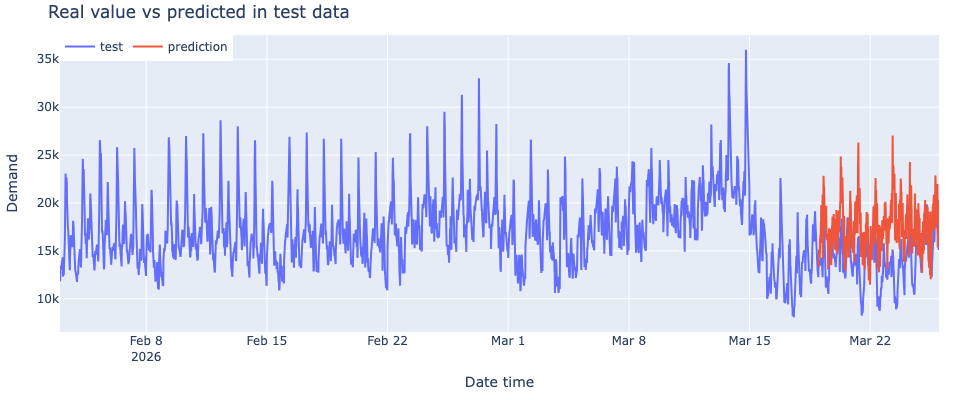

In [275]:
fig = go.Figure()
trace1 = go.Scatter(x=data_indexed.index, y=data_indexed['purchase_bid'], name="test", mode="lines")
trace2 = go.Scatter(x=predictions.index, y=predictions['pred'], name="prediction", mode="lines")
fig.add_trace(trace1)
fig.add_trace(trace2)
fig.update_layout(
    title="Real value vs predicted in test data",
    xaxis_title="Date time",
    yaxis_title="Demand",
    width=800,
    height=400,
    margin=dict(l=20, r=20, t=35, b=20),
    legend=dict(orientation="h", yanchor="top", y=1.01, xanchor="left", x=0)
)
fig.show()

## Feature explanation with SHAP

In [94]:
# Training matrices used by the forecaster to fit the internal estimator
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y               = data_exog['purchase_bid'],
                       exog            = data_exog[exog_features],
                   )
display(X_train.head(3))
display(y_train.head(3))

,lag_1,lag_2,lag_3,lag_95,lag_96,lag_97,lag_191,lag_192,lag_193,lag_287,lag_288,lag_289,roll_mean_288,day_of_week_sin,day_of_week_cos,hour_sin,hour_cos
period_start,,,,,,,,,,,,,,,,,
2026-02-06 00:15:00,13652.400391,13612.500000,13789.200195,14280.700195,13268.900391,12959.900391,12572.599609,12495.400391,12432.000000,13033.599609,12001.799805,11816.400391,16424.108368,-0.433884,-0.900969,0.0,1.0
2026-02-06 00:30:00,13931.000000,13652.400391,13612.500000,14583.500000,14280.700195,13268.900391,12582.400391,12572.599609,12495.400391,13322.099609,13033.599609,12001.799805,16430.806980,-0.433884,-0.900969,0.0,1.0
2026-02-06 00:45:00,14899.599609,13931.000000,13652.400391,14970.500000,14583.500000,14280.700195,12610.700195,12582.400391,12572.599609,13459.299805,13322.099609,13033.599609,16437.286146,-0.433884,-0.900969,0.0,1.0


period_start
2026-02-06 00:15:00    13931.000000
2026-02-06 00:30:00    14899.599609
2026-02-06 00:45:00    15105.799805
Freq: 15min, Name: y, dtype: float32

In [96]:
import shap
# Create SHAP explainer (for three base models)
# ==============================================================================
shap.initjs()
explainer = shap.TreeExplainer(forecaster.estimator)

# Sample 50% of the data to speed up the calculation
rng = np.random.default_rng(seed=785412)
sample = rng.choice(X_train.index, size=int(len(X_train)*0.5), replace=False)
X_train_sample = X_train.loc[sample, :]
shap_values = explainer.shap_values(X_train_sample)

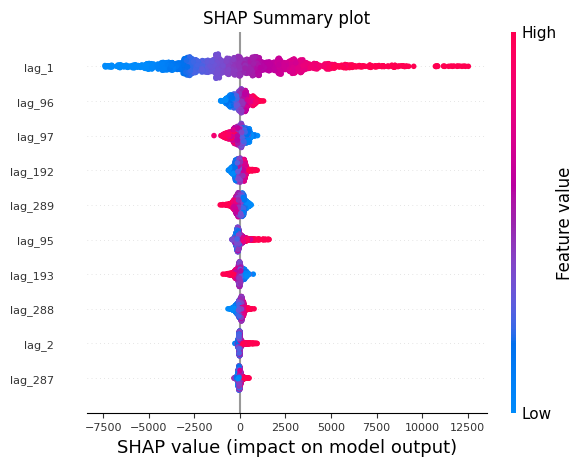

In [97]:
shap.summary_plot(shap_values, X_train_sample, max_display=10, show=False)
fig, ax = plt.gcf(), plt.gca()
ax.set_title("SHAP Summary plot")
ax.tick_params(labelsize=8)
fig.set_size_inches(6, 4.5)